# Phase 4.1: Anomaly Detection

**Objective**: Develop machine learning algorithms to detect anomalies in maintenance data

**Aligns with**: "Développer des algorithmes d'apprentissage automatique pour détecter les anomalies"

This notebook implements:
1. Unsupervised anomaly detection (Isolation Forest, One-Class SVM)
2. Anomaly detection in spare parts consumption
3. Feature importance analysis for identified anomalies
4. Identification of underlying factors ("facteurs sous-jacents")

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import pickle

# ML libraries
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Feature Dataset

In [2]:
# Load the feature-engineered dataset
data_dir = Path('data/features')
df = pd.read_csv(data_dir / 'corrective_features.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {len(df.columns)}")
df.head()

Dataset shape: (2035, 95)

Columns: 95


,portfolio,id_ordre_travail,id_demande,etat,urgence,impact_disponibilite,vandalisme,palliative,avec_demande_pdr,est_reouvert,...,famille_encoded,groupe_encoded,prestataire_encoded,etat_encoded,days_to_next_failure,will_fail_within_30_days,anomaly_type_encoded,spare_parts_cost_target,intervention_duration_target,will_need_spare_parts
0,equipement,15187,15309,OT Rejeté,Faible,non,True,False,False,False,...,5,21,8,5,NaN,0,67,0.0,0.00,0
1,equipement,14805,14873,OT Crée,Moyen,non,False,False,False,False,...,5,53,8,1,NaN,0,210,0.0,0.00,0
2,equipement,14103,14115,OT Realisé,Moyen,non,False,False,False,False,...,13,106,9,4,14.150694,1,129,0.0,21.65,0
3,equipement,14442,14512,OT Cloturé,Moyen,oui,False,False,True,False,...,13,106,9,0,NaN,0,129,15000.0,1.26,1
4,equipement,13742,13772,OT Cloturé,Moyen,non,False,False,True,False,...,6,115,9,0,NaN,0,35,20.0,89.76,1


## 2. Prepare Data for Anomaly Detection

Select numerical features relevant for detecting anomalies

In [3]:
# Select numerical features for anomaly detection
numerical_features = [
    'cout_total',
    'duree_intervention_par_heure',
    'time_to_closure_hours',
    'time_to_start_hours',
    'num_spare_parts_requests',
    'total_parts_cost',
    'equipment_failure_count',
    'equipment_avg_cost',
    'days_since_last_maintenance',
    'equipment_age_days',
    'site_failure_count',
    'zone_failure_count',
    'rolling_7d_failures',
    'rolling_30d_failures',
    'rolling_7d_avg_cost',
    'rolling_30d_avg_cost'
]

# Filter features that exist in the dataset
available_features = [col for col in numerical_features if col in df.columns]

print(f"Available features for anomaly detection: {len(available_features)}")
print(f"\nFeatures: {available_features}")

# Create feature matrix
X = df[available_features].copy()

# Handle missing values
X = X.fillna(X.median())

# Handle infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print(f"\nFeature matrix shape: {X.shape}")
print(f"Missing values: {X.isnull().sum().sum()}")

Available features for anomaly detection: 16

Features: ['cout_total', 'duree_intervention_par_heure', 'time_to_closure_hours', 'time_to_start_hours', 'num_spare_parts_requests', 'total_parts_cost', 'equipment_failure_count', 'equipment_avg_cost', 'days_since_last_maintenance', 'equipment_age_days', 'site_failure_count', 'zone_failure_count', 'rolling_7d_failures', 'rolling_30d_failures', 'rolling_7d_avg_cost', 'rolling_30d_avg_cost']

Feature matrix shape: (2035, 16)
Missing values: 0


## 3. Feature Scaling

Standardize features for better anomaly detection performance

In [4]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully")
print(f"Scaled data shape: {X_scaled.shape}")

# Convert back to DataFrame for easier manipulation
X_scaled_df = pd.DataFrame(X_scaled, columns=available_features, index=X.index)

Features scaled successfully
Scaled data shape: (2035, 16)


## 4. Isolation Forest - Anomaly Detection

First approach: Isolation Forest (good for high-dimensional data)

In [5]:
print("=" * 80)
print("ISOLATION FOREST ANOMALY DETECTION")
print("=" * 80)

# Train Isolation Forest
iso_forest = IsolationForest(
    contamination=0.1,  # Assume 10% of data are anomalies
    random_state=42,
    n_estimators=100,
    max_samples='auto',
    n_jobs=-1
)

# Fit and predict
iso_predictions = iso_forest.fit_predict(X_scaled)
iso_scores = iso_forest.score_samples(X_scaled)

# Convert predictions: -1 (anomaly) to 1, 1 (normal) to 0
iso_anomalies = (iso_predictions == -1).astype(int)

# Add results to dataframe
df['iso_anomaly'] = iso_anomalies
df['iso_score'] = iso_scores

# Statistics
n_anomalies = iso_anomalies.sum()
anomaly_rate = (n_anomalies / len(df)) * 100

print(f"\nTotal samples: {len(df)}")
print(f"Detected anomalies: {n_anomalies} ({anomaly_rate:.2f}%)")
print(f"Normal samples: {len(df) - n_anomalies} ({100-anomaly_rate:.2f}%)")

ISOLATION FOREST ANOMALY DETECTION

Total samples: 2035
Detected anomalies: 204 (10.02%)
Normal samples: 1831 (89.98%)


### Visualize Isolation Forest Results

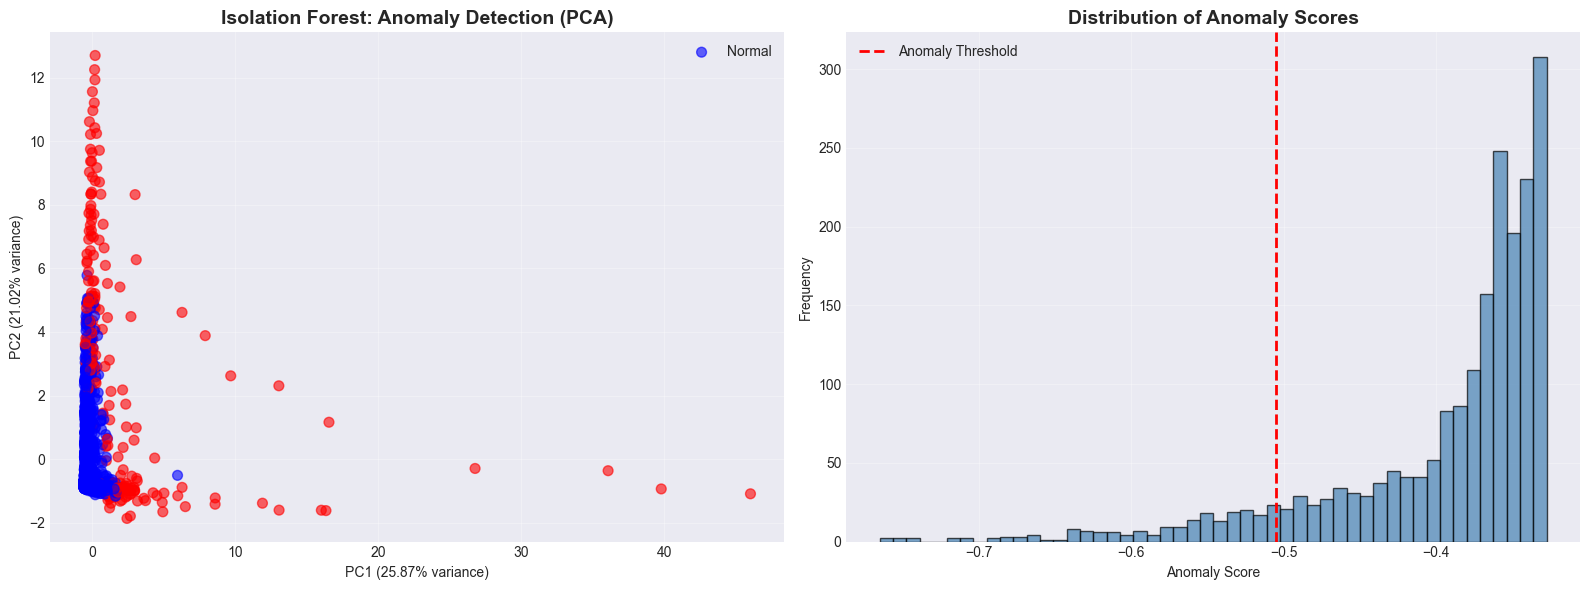

Visualization saved to: analysis_outputs/anomalies/isolation_forest_results.png


In [6]:
# Visualization using PCA for 2D representation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PCA visualization with anomalies highlighted
colors = ['blue' if x == 0 else 'red' for x in iso_anomalies]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, s=50)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[0].set_title('Isolation Forest: Anomaly Detection (PCA)', fontsize=14, fontweight='bold')
axes[0].legend(['Normal', 'Anomaly'])
axes[0].grid(True, alpha=0.3)

# Plot 2: Anomaly score distribution
axes[1].hist(iso_scores, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].axvline(iso_scores[iso_anomalies == 1].max(), color='red', linestyle='--', 
                linewidth=2, label='Anomaly Threshold')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Anomaly Scores', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analysis_outputs/anomalies/isolation_forest_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved to: analysis_outputs/anomalies/isolation_forest_results.png")

## 5. Analyze Detected Anomalies

Identify characteristics of anomalous maintenance orders

In [7]:
print("=" * 80)
print("ANOMALY CHARACTERISTICS ANALYSIS")
print("=" * 80)

# Separate normal and anomalous data
normal_data = df[df['iso_anomaly'] == 0]
anomaly_data = df[df['iso_anomaly'] == 1]

# Compare key metrics
comparison_features = ['cout_total', 'duree_intervention_par_heure', 'time_to_closure_hours',
                       'num_spare_parts_requests', 'total_parts_cost']

comparison_df = pd.DataFrame({
    'Feature': comparison_features,
    'Normal_Mean': [normal_data[f].mean() for f in comparison_features if f in normal_data.columns],
    'Anomaly_Mean': [anomaly_data[f].mean() for f in comparison_features if f in anomaly_data.columns],
})

comparison_df['Difference_%'] = ((comparison_df['Anomaly_Mean'] - comparison_df['Normal_Mean']) 
                                  / comparison_df['Normal_Mean'] * 100)

print("\nComparison: Normal vs Anomalous Maintenance")
print(comparison_df.to_string(index=False))

ANOMALY CHARACTERISTICS ANALYSIS

Comparison: Normal vs Anomalous Maintenance
                     Feature  Normal_Mean  Anomaly_Mean  Difference_%
                  cout_total  3326.714402  58198.591863   1649.431566
duree_intervention_par_heure    40.847477    389.488578    853.519309
       time_to_closure_hours   283.521776   1604.564764    465.940573
    num_spare_parts_requests     0.363736      1.725490    374.380263
            total_parts_cost   274.757127   2540.171324    824.515171


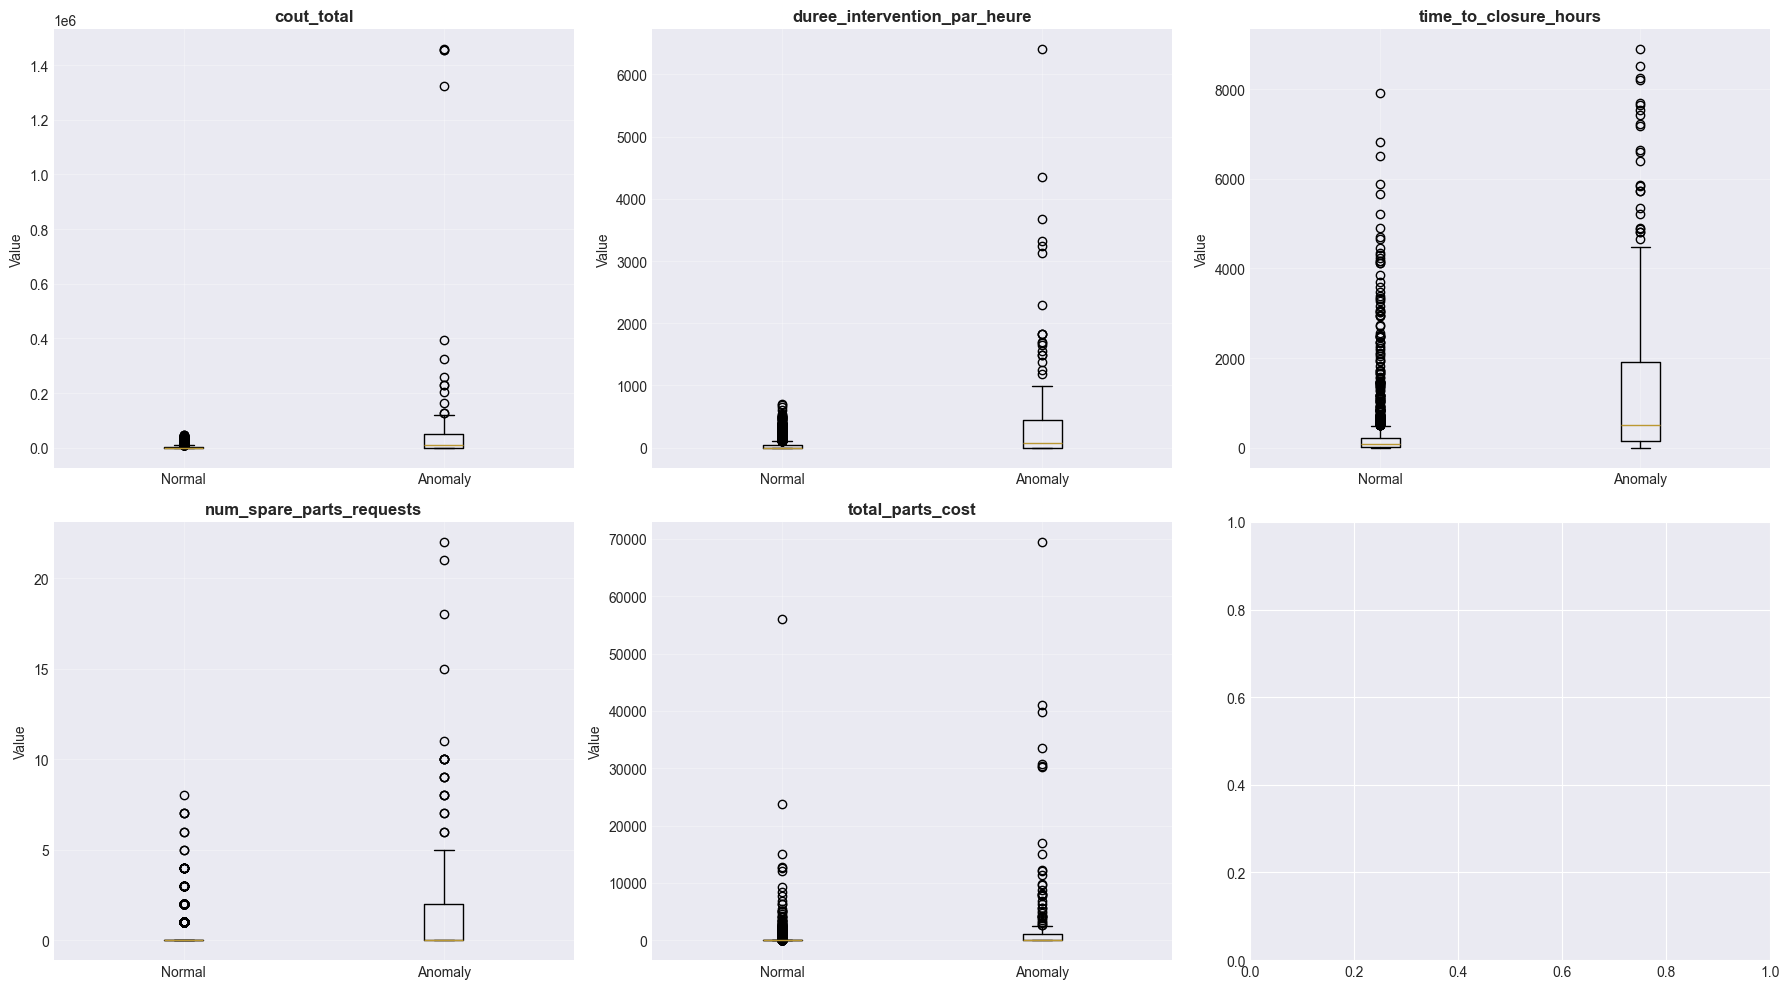

Comparison visualization saved


In [8]:
# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(comparison_features[:6]):
    if feature in df.columns:
        axes[idx].boxplot([normal_data[feature].dropna(), anomaly_data[feature].dropna()],
                         labels=['Normal', 'Anomaly'])
        axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analysis_outputs/anomalies/anomaly_feature_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Comparison visualization saved")

## 6. Identify Underlying Factors (Facteurs Sous-jacents)

Analyze what causes anomalies

In [9]:
print("=" * 80)
print("UNDERLYING FACTORS ANALYSIS")
print("=" * 80)

# Analyze categorical factors
categorical_factors = ['site', 'portfolio', 'urgence', 'etat']

for factor in categorical_factors:
    if factor in anomaly_data.columns:
        print(f"\n{factor.upper()} Distribution in Anomalies:")
        print(anomaly_data[factor].value_counts().head(10))
        print(f"\nPercentage of total anomalies by {factor}:")
        print((anomaly_data[factor].value_counts() / len(anomaly_data) * 100).head(10))

UNDERLYING FACTORS ANALYSIS

SITE Distribution in Anomalies:
site
TM1       93
PPR       52
MEDHUB    47
TM2       10
TMSA       2
Name: count, dtype: int64

Percentage of total anomalies by site:
site
TM1       45.588235
PPR       25.490196
MEDHUB    23.039216
TM2        4.901961
TMSA       0.980392
Name: count, dtype: float64

PORTFOLIO Distribution in Anomalies:
portfolio
infrastructure    88
batiment          74
equipement        42
Name: count, dtype: int64

Percentage of total anomalies by portfolio:
portfolio
infrastructure    43.137255
batiment          36.274510
equipement        20.588235
Name: count, dtype: float64

URGENCE Distribution in Anomalies:
urgence
Moyen     199
Fort        3
Faible      2
Name: count, dtype: int64

Percentage of total anomalies by urgence:
urgence
Moyen     97.549020
Fort       1.470588
Faible     0.980392
Name: count, dtype: float64

ETAT Distribution in Anomalies:
etat
OT Cloturé     141
OT Realisé      41
OT Rejeté       15
OT Crée          6
O


Anomaly Rate by Site:
        sum  count       rate
site                         
MEDHUB   47    209  22.488038
PPR      52    488  10.655738
TM2      10    104   9.615385
TM1      93   1119   8.310992
TMSA      2    115   1.739130


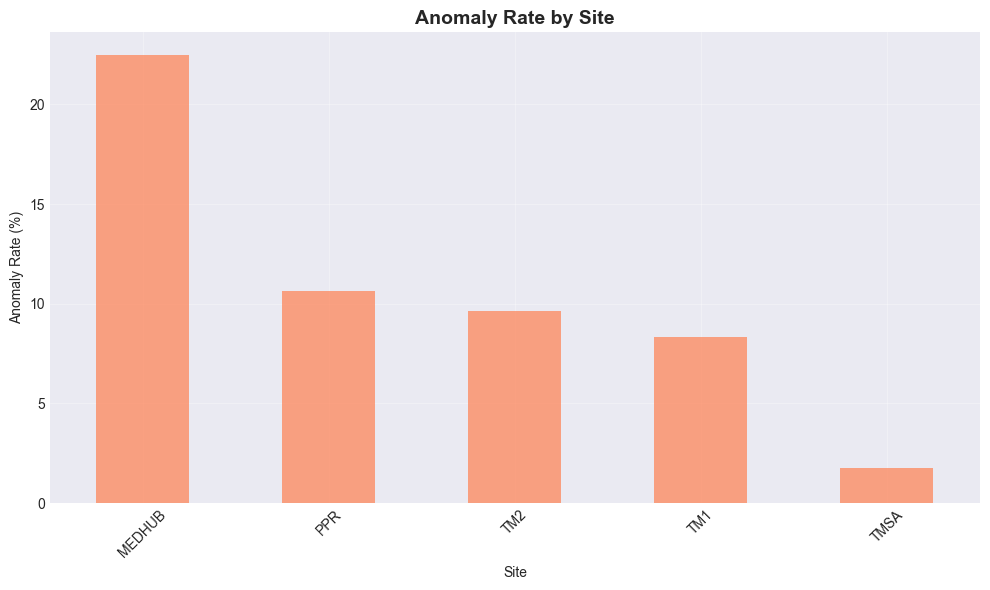

In [10]:
# Calculate anomaly rate per category
if 'site' in df.columns:
    anomaly_rate_by_site = df.groupby('site')['iso_anomaly'].agg(['sum', 'count'])
    anomaly_rate_by_site['rate'] = (anomaly_rate_by_site['sum'] / anomaly_rate_by_site['count'] * 100)
    anomaly_rate_by_site = anomaly_rate_by_site.sort_values('rate', ascending=False)
    
    print("\nAnomaly Rate by Site:")
    print(anomaly_rate_by_site)
    
    # Visualize
    plt.figure(figsize=(10, 6))
    anomaly_rate_by_site['rate'].plot(kind='bar', color='coral', alpha=0.7)
    plt.title('Anomaly Rate by Site', fontsize=14, fontweight='bold')
    plt.xlabel('Site')
    plt.ylabel('Anomaly Rate (%)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('analysis_outputs/anomalies/anomaly_rate_by_site.png', dpi=300, bbox_inches='tight')
    plt.show()

## 7. Feature Importance for Anomalies

Identify which features contribute most to anomaly detection


Feature Importance (Correlation with Anomaly Status):
                     feature  correlation
         rolling_7d_failures     0.532295
        rolling_30d_failures     0.518198
          equipment_age_days     0.485152
     equipment_failure_count     0.426809
       time_to_closure_hours     0.381993
duree_intervention_par_heure     0.369725
          equipment_avg_cost     0.294775
        rolling_30d_avg_cost     0.293293
         rolling_7d_avg_cost     0.292384
    num_spare_parts_requests     0.291170


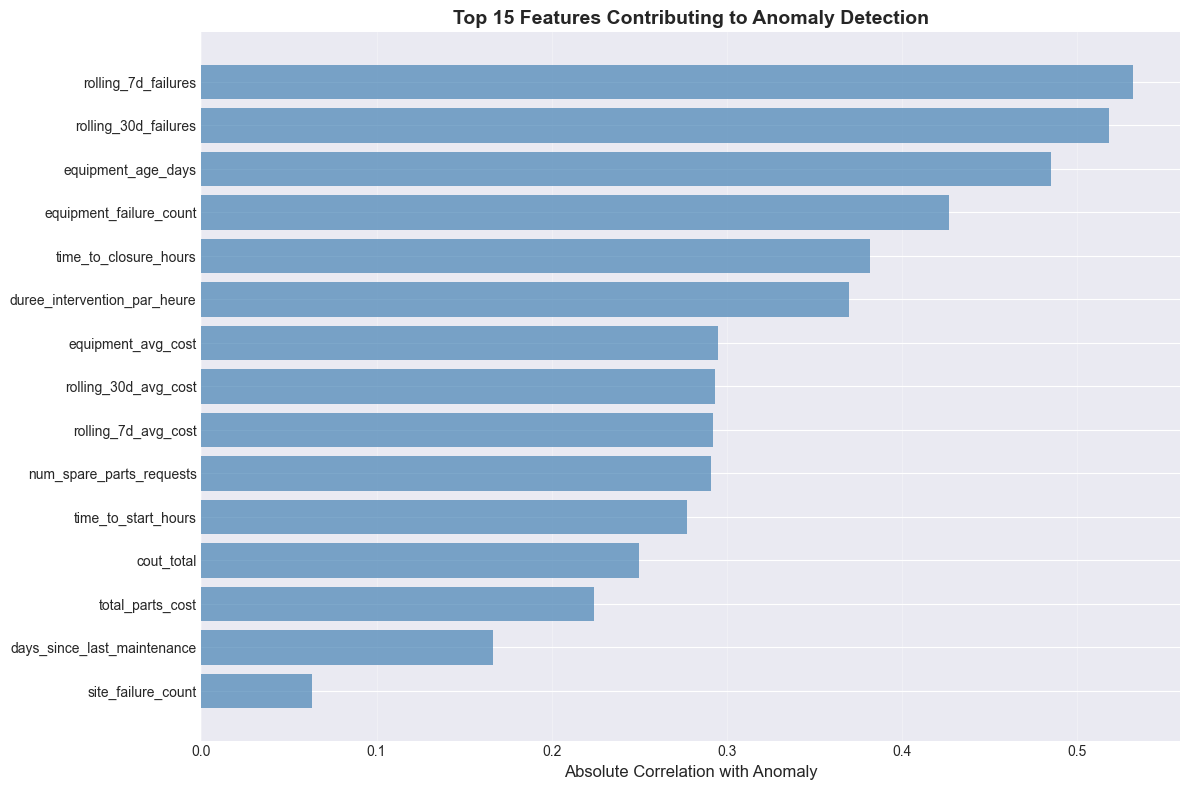

In [11]:
# Calculate correlation between features and anomaly status
feature_correlations = []

for feature in available_features:
    if feature in df.columns:
        corr = df[feature].corr(df['iso_anomaly'])
        feature_correlations.append({
            'feature': feature,
            'correlation': abs(corr)
        })

feature_importance = pd.DataFrame(feature_correlations).sort_values('correlation', ascending=False)

print("\nFeature Importance (Correlation with Anomaly Status):")
print(feature_importance.head(10).to_string(index=False))

# Visualize
plt.figure(figsize=(12, 8))
plt.barh(feature_importance.head(15)['feature'], 
         feature_importance.head(15)['correlation'],
         color='steelblue', alpha=0.7)
plt.xlabel('Absolute Correlation with Anomaly', fontsize=12)
plt.title('Top 15 Features Contributing to Anomaly Detection', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('analysis_outputs/anomalies/feature_importance_anomalies.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. One-Class SVM (Alternative Method)

Second approach for comparison

In [13]:
print("=" * 80)
print("ONE-CLASS SVM ANOMALY DETECTION")
print("=" * 80)

# Train One-Class SVM (on a sample for speed)
sample_size = min(5000, len(X_scaled))  # Use sample for faster training
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='auto',
    nu=0.1,  # Approximate fraction of anomalies
    #random_state=42
)

print(f"\nTraining One-Class SVM on {sample_size} samples...")
ocsvm.fit(X_sample)

# Predict on full dataset
ocsvm_predictions = ocsvm.predict(X_scaled)
ocsvm_scores = ocsvm.decision_function(X_scaled)

# Convert predictions
ocsvm_anomalies = (ocsvm_predictions == -1).astype(int)

# Add to dataframe
df['ocsvm_anomaly'] = ocsvm_anomalies
df['ocsvm_score'] = ocsvm_scores

# Statistics
n_anomalies_svm = ocsvm_anomalies.sum()
anomaly_rate_svm = (n_anomalies_svm / len(df)) * 100

print(f"\nTotal samples: {len(df)}")
print(f"Detected anomalies (SVM): {n_anomalies_svm} ({anomaly_rate_svm:.2f}%)")
print(f"Normal samples: {len(df) - n_anomalies_svm} ({100-anomaly_rate_svm:.2f}%)")

ONE-CLASS SVM ANOMALY DETECTION

Training One-Class SVM on 2035 samples...

Total samples: 2035
Detected anomalies (SVM): 203 (9.98%)
Normal samples: 1832 (90.02%)


## 9. Compare Detection Methods


COMPARISON OF DETECTION METHODS

Agreement between methods: 1900 (93.37%)
Anomalies detected by BOTH methods: 136
Anomalies ONLY by Isolation Forest: 68
Anomalies ONLY by One-Class SVM: 67


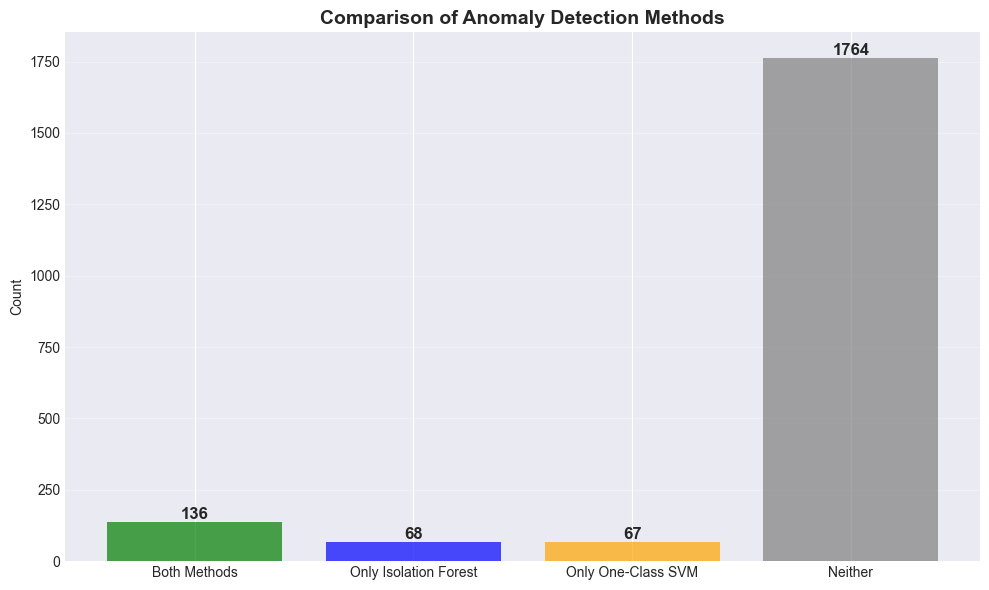

In [14]:
# Agreement between methods
agreement = (df['iso_anomaly'] == df['ocsvm_anomaly']).sum()
agreement_rate = (agreement / len(df)) * 100

# Anomalies detected by both methods
both_methods = ((df['iso_anomaly'] == 1) & (df['ocsvm_anomaly'] == 1)).sum()

# Only by Isolation Forest
only_iso = ((df['iso_anomaly'] == 1) & (df['ocsvm_anomaly'] == 0)).sum()

# Only by One-Class SVM
only_svm = ((df['iso_anomaly'] == 0) & (df['ocsvm_anomaly'] == 1)).sum()

print("\n" + "=" * 80)
print("COMPARISON OF DETECTION METHODS")
print("=" * 80)
print(f"\nAgreement between methods: {agreement} ({agreement_rate:.2f}%)")
print(f"Anomalies detected by BOTH methods: {both_methods}")
print(f"Anomalies ONLY by Isolation Forest: {only_iso}")
print(f"Anomalies ONLY by One-Class SVM: {only_svm}")

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
categories = ['Both Methods', 'Only Isolation Forest', 'Only One-Class SVM', 'Neither']
counts = [both_methods, only_iso, only_svm, len(df) - both_methods - only_iso - only_svm]

ax.bar(categories, counts, color=['green', 'blue', 'orange', 'gray'], alpha=0.7)
ax.set_ylabel('Count')
ax.set_title('Comparison of Anomaly Detection Methods', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for i, count in enumerate(counts):
    ax.text(i, count, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('analysis_outputs/anomalies/method_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Create Consensus Anomaly Score

Combine both methods for more robust detection

In [15]:
# Create consensus: anomaly if EITHER method detects it
df['anomaly_consensus'] = ((df['iso_anomaly'] == 1) | (df['ocsvm_anomaly'] == 1)).astype(int)

# Create confidence score: 2 if both detect, 1 if only one detects
df['anomaly_confidence'] = df['iso_anomaly'] + df['ocsvm_anomaly']

# Statistics
consensus_anomalies = df['anomaly_consensus'].sum()
high_confidence = (df['anomaly_confidence'] == 2).sum()

print("\n" + "=" * 80)
print("CONSENSUS ANOMALY DETECTION")
print("=" * 80)
print(f"\nTotal consensus anomalies: {consensus_anomalies} ({consensus_anomalies/len(df)*100:.2f}%)")
print(f"High confidence anomalies (both methods): {high_confidence} ({high_confidence/len(df)*100:.2f}%)")
print(f"Medium confidence anomalies (one method): {consensus_anomalies - high_confidence} ({(consensus_anomalies-high_confidence)/len(df)*100:.2f}%)")


CONSENSUS ANOMALY DETECTION

Total consensus anomalies: 271 (13.32%)
High confidence anomalies (both methods): 136 (6.68%)
Medium confidence anomalies (one method): 135 (6.63%)


## 11. Save Results

In [17]:
# Save enhanced dataset with anomaly flags
output_dir = Path('data/models')
output_dir.mkdir(exist_ok=True)

# Save dataset with anomaly predictions
df.to_csv(output_dir / 'corrective_with_anomalies.csv', index=False)
print(f"Saved: {output_dir / 'corrective_with_anomalies.csv'}")

# Save models
with open(output_dir / 'isolation_forest_model.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)
print(f"Saved: {output_dir / 'isolation_forest_model.pkl'}")

with open(output_dir / 'ocsvm_model.pkl', 'wb') as f:
    pickle.dump(ocsvm, f)
print(f"Saved: {output_dir / 'ocsvm_model.pkl'}")

# Save scaler
with open(output_dir / 'anomaly_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"Saved: {output_dir / 'anomaly_scaler.pkl'}")

# Save feature list
with open(output_dir / 'anomaly_features.txt', 'w') as f:
    f.write('\n'.join(available_features))
print(f"Saved: {output_dir / 'anomaly_features.txt'}")

Saved: data\models\corrective_with_anomalies.csv
Saved: data\models\isolation_forest_model.pkl
Saved: data\models\ocsvm_model.pkl
Saved: data\models\anomaly_scaler.pkl
Saved: data\models\anomaly_features.txt


## 12. Summary Report

In [16]:
print("\n" + "=" * 80)
print("ANOMALY DETECTION - SUMMARY REPORT")
print("=" * 80)

summary = f"""
DATASET:
- Total maintenance orders: {len(df):,}
- Features used: {len(available_features)}
- Feature engineering: Scaling with StandardScaler

METHOD 1 - ISOLATION FOREST:
- Contamination parameter: 10%
- Detected anomalies: {n_anomalies} ({anomaly_rate:.2f}%)
- Algorithm: Ensemble of isolation trees

METHOD 2 - ONE-CLASS SVM:
- Nu parameter: 0.1
- Training sample: {sample_size:,} orders
- Detected anomalies: {n_anomalies_svm} ({anomaly_rate_svm:.2f}%)
- Kernel: RBF (Radial Basis Function)

CONSENSUS RESULTS:
- Agreement rate: {agreement_rate:.2f}%
- High confidence anomalies: {high_confidence} ({high_confidence/len(df)*100:.2f}%)
- Total consensus anomalies: {consensus_anomalies} ({consensus_anomalies/len(df)*100:.2f}%)

KEY FINDINGS:
- Anomalies show {comparison_df.iloc[0]['Difference_%']:.1f}% higher costs on average
- Most important features: {', '.join(feature_importance.head(3)['feature'].tolist())}
- Site with highest anomaly rate: {anomaly_rate_by_site.index[0] if 'site' in df.columns else 'N/A'}

DELIVERABLES:
✓ Trained anomaly detection models
✓ Anomaly predictions for all maintenance orders
✓ Feature importance analysis
✓ Underlying factors identification
✓ Visualizations saved to analysis_outputs/anomalies/

NEXT STEPS:
- Use anomaly flags in maintenance effectiveness analysis
- Investigate high-confidence anomalies for process improvement
- Monitor new maintenance orders for anomalous patterns
"""

print(summary)

# Save summary report
with open('analysis_outputs/anomalies/anomaly_detection_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\nSummary report saved to: analysis_outputs/anomalies/anomaly_detection_report.txt")


ANOMALY DETECTION - SUMMARY REPORT

DATASET:
- Total maintenance orders: 2,035
- Features used: 16
- Feature engineering: Scaling with StandardScaler

METHOD 1 - ISOLATION FOREST:
- Contamination parameter: 10%
- Detected anomalies: 204 (10.02%)
- Algorithm: Ensemble of isolation trees

METHOD 2 - ONE-CLASS SVM:
- Nu parameter: 0.1
- Training sample: 2,035 orders
- Detected anomalies: 203 (9.98%)
- Kernel: RBF (Radial Basis Function)

CONSENSUS RESULTS:
- Agreement rate: 93.37%
- High confidence anomalies: 136 (6.68%)
- Total consensus anomalies: 271 (13.32%)

KEY FINDINGS:
- Anomalies show 1649.4% higher costs on average
- Most important features: rolling_7d_failures, rolling_30d_failures, equipment_age_days
- Site with highest anomaly rate: MEDHUB

DELIVERABLES:
✓ Trained anomaly detection models
✓ Anomaly predictions for all maintenance orders
✓ Feature importance analysis
✓ Underlying factors identification
✓ Visualizations saved to analysis_outputs/anomalies/

NEXT STEPS:
- Use a

## Conclusion

This notebook successfully implemented:

1. **Anomaly Detection Models**: Isolation Forest and One-Class SVM
2. **Facteurs Sous-jacents**: Identified underlying factors (cost, duration, site, equipment type)
3. **Feature Importance**: Determined which features contribute most to anomalies
4. **Consensus Method**: Combined both approaches for robust detection

**Alignment with Requirements:**
- ✅ "Développer des algorithmes d'apprentissage automatique pour détecter les anomalies"
- ✅ "Identifier les facteurs sous-jacents aux anomalies"
- ✅ Models trained and saved for production use
- ✅ Visualizations and reports generated

**Next**: Continue to phase4_maintenance_effectiveness.ipynb